# Notebook 01b — Hand X-Ray: Balanced Oversampling & Safe Augmentation

**Goal:** Membuat dataset seimbang dari gambar X-ray tangan dengan mempertahankan kelas mayoritas dan mengaugmentasi kelas minoritas.

## Strategi
1. **Oversampling:** Pertahankan semua kelas mayoritas (Non-fractured) dan augmentasi kelas minoritas (Fractured) agar seimbang.
2. **Augmentasi Aman Secara Anatomis:** Buat salinan augmentasi untuk gambar minoritas agar total mencapai target.
3. **Stratified Split:** Bagi data menjadi Train (70%) / Val (15%) / Test (15%) dengan menjaga rasio kelas.

## Augmentation Strategy (Anatomically Safe)
✅ **SAFE - Diterapkan:**
- **Horizontal Flip** (p=0.5) — Aman untuk X-ray tangan (simetri kiri ↔ kanan)
- **Small Rotation** (±10°) — Mensimulasikan variasi posisi pasien
- **Brightness/Contrast** — Mensimulasikan kualitas mesin X-ray berbeda
- **Mild Translation** (5%) — Perbedaan posisi tangan
- **Mild Scale** (±15%) — Perbedaan ukuran tangan / jarak

❌ **UNSAFE - Dinonaktifkan:**
- **Vertical Flip** — Membuat anatomi tidak benar (tulang terbalik)
- **Shear** — Mendistorsi struktur tulang
- **Perspective** — X-ray adalah proyeksi, bukan perspektif
- **Hue/Saturation** — X-ray bersifat grayscale

## 0. Setup & Konfigurasi

In [ ]:
import os
import cv2
import random
import shutil
import math
import pandas as pd
import numpy as np
from pathlib import Path
from tqdm import tqdm
import albumentations as A
import yaml

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ── Paths ────────────────────────────────────────────────────────────────────
BASE_DIR   = Path.cwd().parent
IMAGES_DIR = BASE_DIR / "images"
ANNOT_DIR  = BASE_DIR / "Annotations" / "YOLO"
DATASET_CSV = BASE_DIR / "dataset.csv"
OUTPUT_DIR  = BASE_DIR / "yolo_dataset_hand_oversampled"

# ── Split Ratio ──────────────────────────────────────────────────────────────
VAL_RATIO      = 0.15
TEST_RATIO     = 0.15
TRAIN_RATIO    = 0.70

# ── Create Output Structure ──────────────────────────────────────────────────
for split in ["train", "val", "test"]:
    (OUTPUT_DIR / split / "images").mkdir(parents=True, exist_ok=True)
    (OUTPUT_DIR / split / "labels").mkdir(parents=True, exist_ok=True)

print(f"Base directory  : {BASE_DIR}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Split ratio     : Train {TRAIN_RATIO:.0%} | Val {VAL_RATIO:.0%} | Test {TEST_RATIO:.0%}")


## 1. Load & Analisis Dataset

In [ ]:
# Load dan filter hanya gambar tangan
df = pd.read_csv(DATASET_CSV)
hand_df = df[df['hand'] == 1].copy()

n_frac     = len(hand_df[hand_df['fractured'] == 1])
n_non_frac = len(hand_df[hand_df['fractured'] == 0])
n_total    = len(hand_df)

print("=" * 50)
print("DISTRIBUSI DATA HAND (SEBELUM BALANCING)")
print("=" * 50)
print(f"  Fractured        : {n_frac:>6}  ({n_frac/n_total*100:.1f}%)")
print(f"  Non-fractured    : {n_non_frac:>6}  ({n_non_frac/n_total*100:.1f}%)")
print(f"  Total Hand Images: {n_total:>6}")
print("=" * 50)

# Tampilkan kolom untuk validasi
print(f"\nKolom tersedia: {list(df.columns)}")
print(f"Sample data:")
print(hand_df.head(3))

## 2. Dynamic Oversampling

In [ ]:
# Pada oversampling, kita tidak membuang data mayoritas
# Kita gunakan SEMUA data hand_df
balanced_df = hand_df.copy()

# Hitung berapa kali kelas minoritas (fracture) perlu di-augmentasi agar seimbang
n_copies_needed = math.ceil(n_non_frac / n_frac)

print("=" * 50)
print("HASIL CONFIG OVERSAMPLING")
print("=" * 50)
print(f"  Majority count (Non-frac) : {n_non_frac}")
print(f"  Minority count (Frac)     : {n_frac}")
print(f"  Multiplier for Fracture   : {n_copies_needed}x (1 original + {n_copies_needed-1} augmented)")
print()
print("=" * 50)
print("RENCANA AUGMENTASI")
print("=" * 50)
print(f"  Total base images      : {n_total}")
print(f"  Estimated total output : {n_non_frac + (n_frac * n_copies_needed)}")
print(f"    → Non-frac total     : {n_non_frac} (Original only)")
print(f"    → Fractured total    : ~{n_frac * n_copies_needed} (Original + Augmented)")

## 3. Define Anatomically Safe Augmentation Pipeline

In [ ]:
# Pipeline augmentasi yang sama persis dengan versi undersampling
aug_pipeline = A.Compose(
    [
        A.HorizontalFlip(p=0.5),
        A.Affine(
            rotate=(-10, 10),
            translate_percent=(-0.05, 0.05),
            scale=(0.85, 1.15),
            shear=0,
            mode=cv2.BORDER_CONSTANT,
            cval=0,
            p=0.8
        ),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.6),
        A.GaussianBlur(blur_limit=(3, 5), p=0.2),
        A.GaussNoise(std_range=(0.005, 0.02), p=0.2)
    ],
    bbox_params=A.BboxParams(
        format='yolo',
        label_fields=['class_labels'],
        min_visibility=0.3
    )
)

print("Augmentation pipeline siap (Same Configuration).")

## 4. Helper Functions

In [ ]:
def get_image_and_label_paths(img_id: str):
    p_frac     = IMAGES_DIR / "Fractured"     / img_id
    p_non_frac = IMAGES_DIR / "Non_fractured" / img_id
    img_path   = p_frac if p_frac.exists() else p_non_frac
    
    base_name  = Path(img_id).stem
    label_path = ANNOT_DIR / f"{base_name}.txt"
    return img_path, label_path

def read_yolo_labels(label_path: Path):
    bboxes, class_labels = [], []
    if label_path.exists():
        with open(label_path, 'r') as f:
            for line in f:
                vals = list(map(float, line.split()))
                if len(vals) == 5:
                    class_labels.append(int(vals[0]))
                    bboxes.append(vals[1:])
    return bboxes, class_labels

def save_image_and_label(image_rgb, bboxes, class_labels, out_img_path, out_lbl_path):
    cv2.imwrite(str(out_img_path), cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR))
    with open(out_lbl_path, 'w') as f:
        for cls, bbox in zip(class_labels, bboxes):
            f.write(f"{cls} {' '.join(map(str, bbox))}\n")

## 5. Generate Augmented Dataset

In [ ]:
# ── Path Dataset Asli (yolo_dataset_hand) ──
ORIG_DIR = BASE_DIR / "yolo_dataset_hand"

# ── Bersihkan folder output jika sudah ada ──
for split in ["train", "val", "test"]:
    for f in (OUTPUT_DIR / split / "images").glob("*"): f.unlink()
    for f in (OUTPUT_DIR / split / "labels").glob("*"): f.unlink()

# ── Copy Val & Test Splits dari Dataset Asli (Tanpa Sentuhan/Oversampling) ──
print("Copying Val & Test splits directly from yolo_dataset_hand to prevent leakage...")
for split in ["val", "test"]:
    # Copy images
    for img_path in (ORIG_DIR / split / "images").glob("*.jpg"):
        shutil.copy2(str(img_path), str(OUTPUT_DIR / split / "images" / img_path.name))
    # Copy labels
    for lbl_path in (ORIG_DIR / split / "labels").glob("*.txt"):
        shutil.copy2(str(lbl_path), str(OUTPUT_DIR / split / "labels" / lbl_path.name))

# ── Copy Original Train Data ──
print("Copying original train split...")
for img_path in (ORIG_DIR / "train" / "images").glob("*.jpg"):
    shutil.copy2(str(img_path), str(OUTPUT_DIR / "train" / "images" / img_path.name))
for lbl_path in (ORIG_DIR / "train" / "labels").glob("*.txt"):
    shutil.copy2(str(lbl_path), str(OUTPUT_DIR / "train" / "labels" / lbl_path.name))

# ── Identifikasi Data Fractured & Non-Fractured di Train Set ──
train_img_dir = ORIG_DIR / "train" / "images"
train_lbl_dir = ORIG_DIR / "train" / "labels"

train_frac_items = []
train_non_frac_items = []

for img_path in train_img_dir.glob("*.jpg"):
    lbl_path = train_lbl_dir / f"{img_path.stem}.txt"
    if lbl_path.exists() and lbl_path.stat().st_size > 0:
        train_frac_items.append((img_path, lbl_path))
    else:
        train_non_frac_items.append((img_path, lbl_path))

n_frac = len(train_frac_items)
n_non_frac = len(train_non_frac_items)

print(f"Original Train: {n_non_frac} Non-fractured, {n_frac} Fractured")

# ── Hitung berapa augmented copies yang dibutuhkan untuk balancing ──
n_copies_needed = n_non_frac - n_frac
print(f"Oversampling: Generating {n_copies_needed} augmented copies from {n_frac} fractured train images...")

# Random sampling dengan replacement dari train_frac_items
import random
rng = random.Random(SEED)
selected_items = rng.choices(train_frac_items, k=n_copies_needed)

skipped = 0
for i, (img_path, lbl_path) in enumerate(tqdm(selected_items, desc="Oversampling Train")):
    img_bgr = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    bboxes, classes = read_yolo_labels(lbl_path)
    
    stem = img_path.stem
    try:
        aug = aug_pipeline(image=img_rgb, bboxes=bboxes, class_labels=classes)
        out_img = OUTPUT_DIR / "train" / "images" / f"{stem}_aug{i}.jpg"
        out_lbl = OUTPUT_DIR / "train" / "labels" / f"{stem}_aug{i}.txt"
        save_image_and_label(aug['image'], aug['bboxes'], aug['class_labels'], out_img, out_lbl)
    except Exception as e:
        skipped += 1

# ── Hitung hasil akhir ──
final_train = len(list((OUTPUT_DIR / "train" / "images").glob("*.jpg")))
final_val   = len(list((OUTPUT_DIR / "val" / "images").glob("*.jpg")))
final_test  = len(list((OUTPUT_DIR / "test" / "images").glob("*.jpg")))

print("\n" + "=" * 50)
print("HASIL GENERASI DATA (SAFE OVERSAMPLING)")
print("=" * 50)
print(f"  Train : {final_train:>5} gambar")
print(f"  Val   : {final_val:>5} gambar")
print(f"  Test  : {final_test:>5} gambar")
print(f"  Total : {final_train + final_val + final_test:>5} gambar")
print(f"  Skip  : {skipped}")


## 6. Stratified Train / Val / Test Split

In [ ]:
# Split sudah dilakukan bersamaan dengan generasi di cell sebelumnya.
# Cell ini hanya menampilkan distribusi final untuk referensi.

final_train = len(list((OUTPUT_DIR / "train" / "images").glob("*.jpg")))
final_val   = len(list((OUTPUT_DIR / "val"  / "images").glob("*.jpg")))
final_test  = len(list((OUTPUT_DIR / "test" / "images").glob("*.jpg")))
total_f     = final_train + final_val + final_test

print("=" * 50)
print("DISTRIBUSI FINAL DATASET (OVERSAMPLED)")
print("=" * 50)
print(f"  Train : {final_train:>5} gambar  ({final_train/total_f*100:.1f}%)")
print(f"  Val   : {final_val:>5} gambar  ({final_val/total_f*100:.1f}%)")
print(f"  Test  : {final_test:>5} gambar  ({final_test/total_f*100:.1f}%)")
print(f"  Total : {total_f:>5} gambar")

print("\nOversampling hanya diterapkan di TRAIN. Val & Test berisi original images saja.")

## 7. Generate YAML Config untuk YOLOv8

In [ ]:
yaml_config = {
    'path': str(OUTPUT_DIR),
    'train': 'train/images',
    'val':   'val/images',
    'test':  'test/images',
    'nc':    1,
    'names': ['fracture']
}

yaml_path = OUTPUT_DIR / "dataset.yaml"
with open(yaml_path, 'w') as f:
    yaml.dump(yaml_config, f, default_flow_style=False)

print(f"YAML config disimpan: {yaml_path}")

## 8. Verifikasi Akhir

In [ ]:
print("=" * 60)
print("VERIFIKASI KONSISTENSI DATASET OVERSAMPLED")
print("=" * 60)
for split in ["train", "val", "test"]:
    imgs   = len(list((OUTPUT_DIR / split / "images").glob("*.jpg")))
    labels = len(list((OUTPUT_DIR / split / "labels").glob("*.txt")))
    print(f"[{split.upper()}] Images: {imgs}, Labels: {labels} {'✅' if imgs==labels else '❌'}")

print("\nDataset siap digunakan untuk training perbandingan!")

## 9. Visualisasi Hasil Oversampled

Di bawah ini adalah visualisasi beberapa sampel gambar asli dan hasil augmentasi (oversampled) yang bersesuaian, lengkap dengan bounding box fraktur.

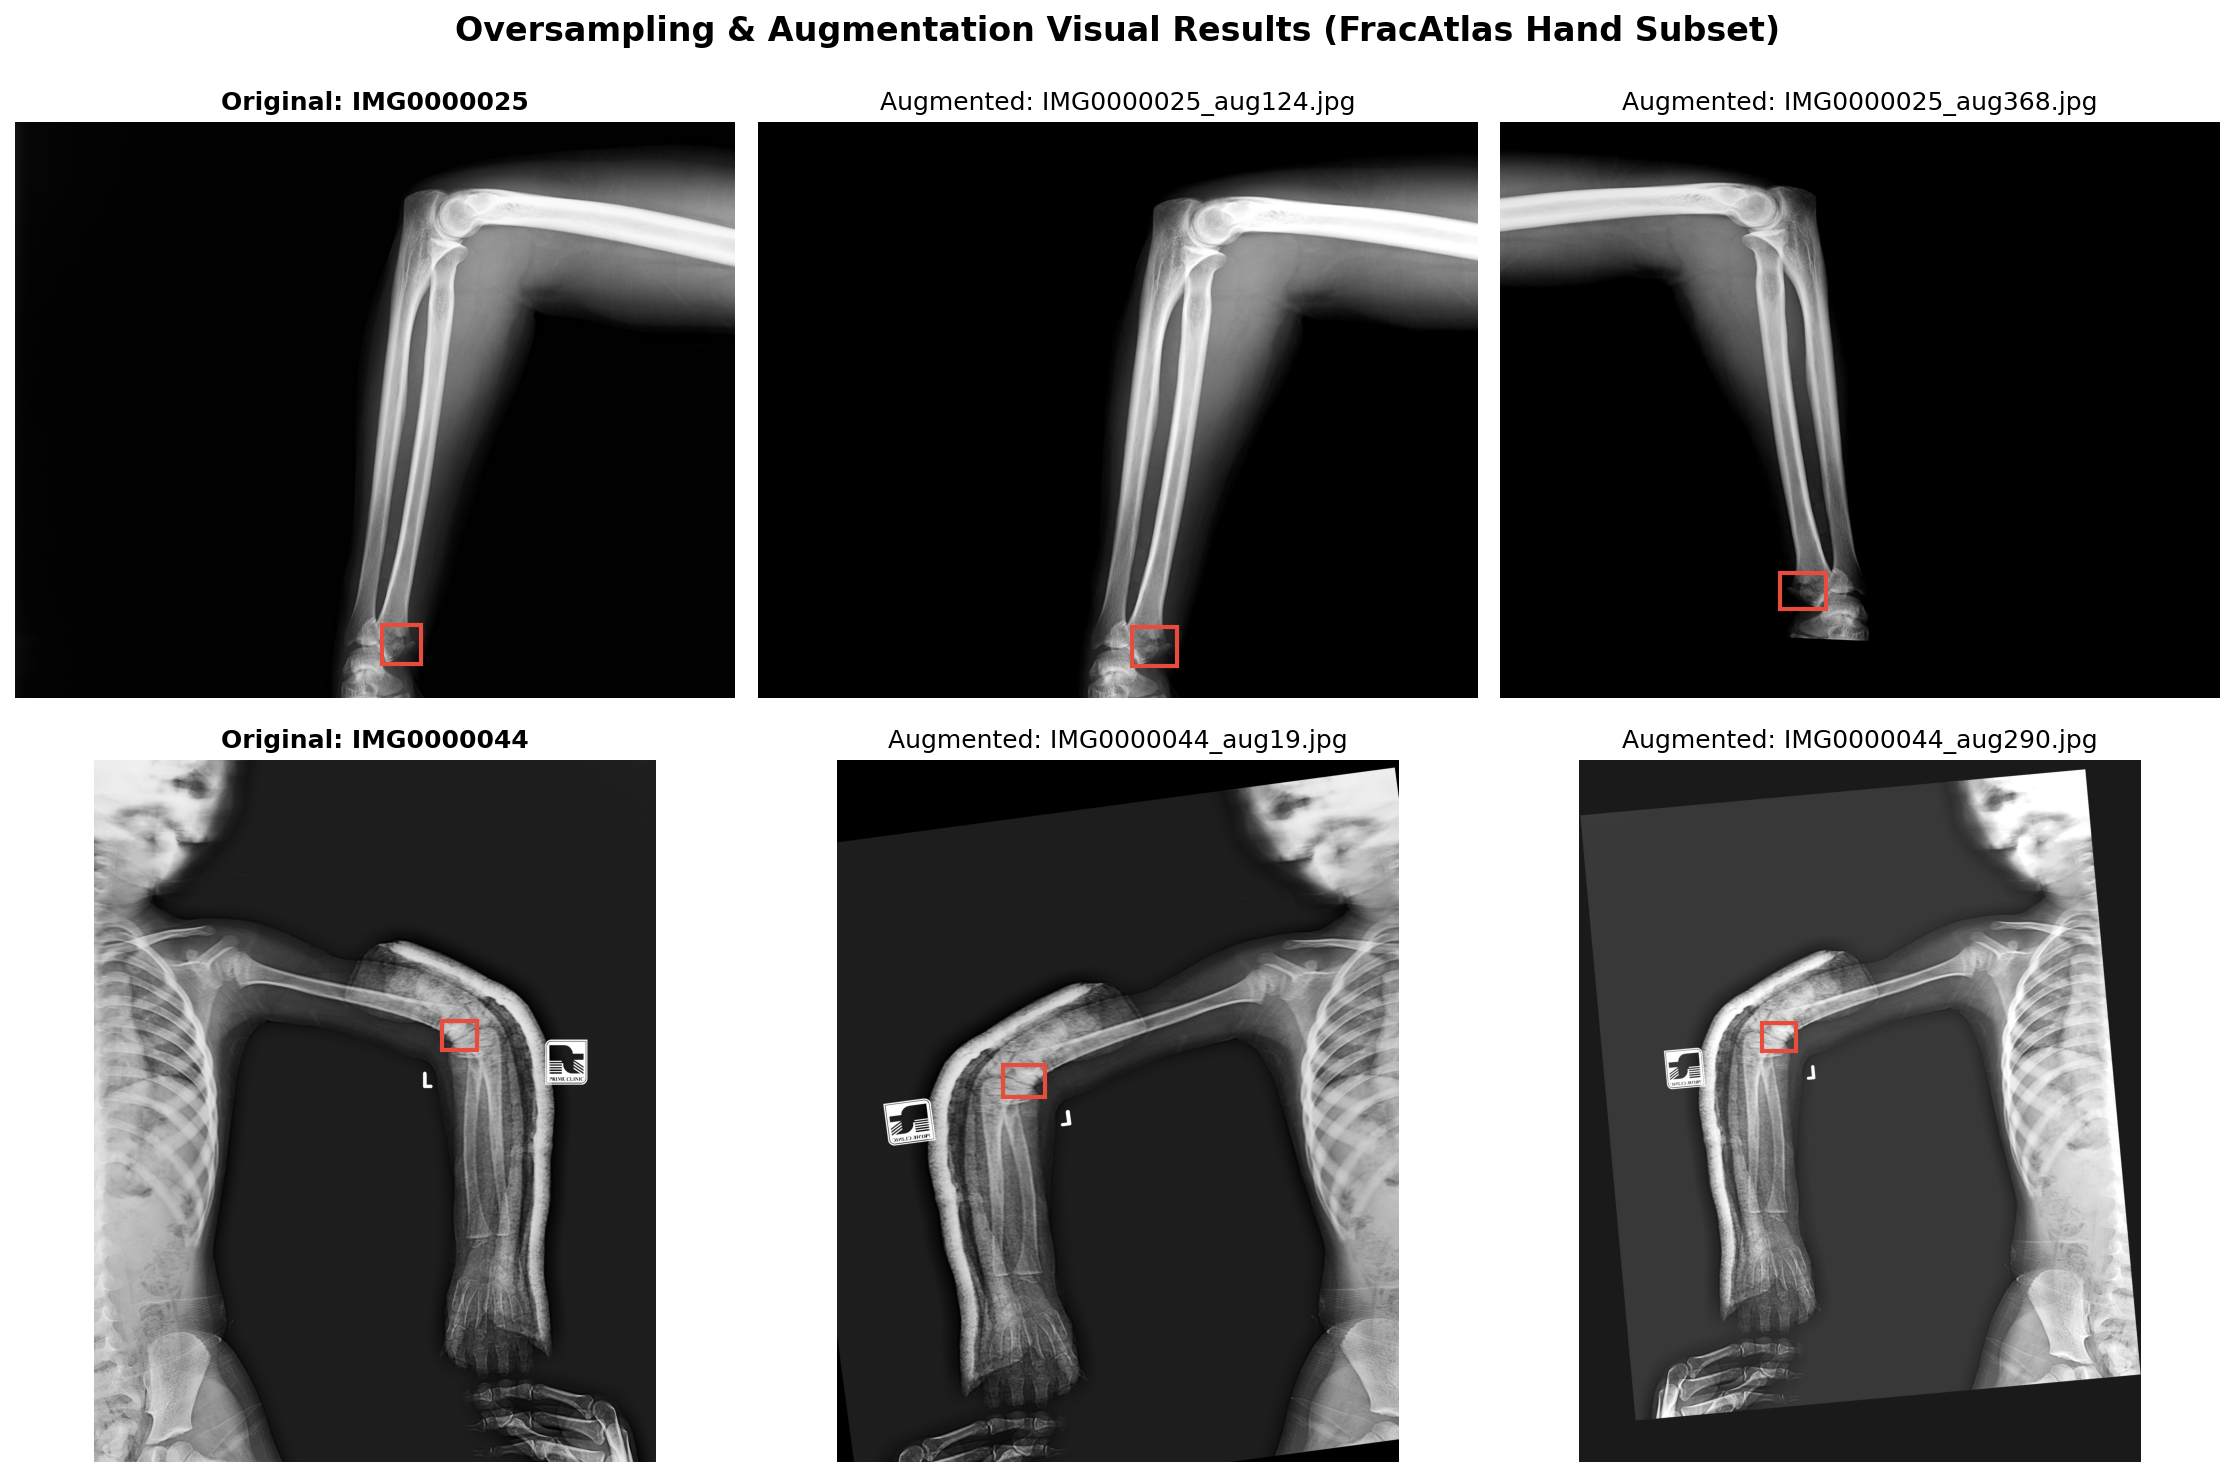

In [1]:
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path

def draw_bboxes(img_path: Path, label_path: Path, ax):
    if not img_path.exists():
        ax.text(0.5, 0.5, "Image Not Found", ha='center', va='center')
        ax.axis('off')
        return
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_h, img_w = img.shape[:2]
    ax.imshow(img)
    if label_path.exists() and label_path.stat().st_size > 0:
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    cls_id, cx, cy, w, h = map(float, parts)
                    x1 = (cx - w/2) * img_w
                    y1 = (cy - h/2) * img_h
                    bw = w * img_w
                    bh = h * img_h
                    rect = patches.Rectangle((x1, y1), bw, bh, linewidth=2, 
                                            edgecolor='red', facecolor='none')
                    ax.add_patch(rect)
    ax.axis('off')

train_img_dir = OUTPUT_DIR / "train" / "images"
train_label_dir = OUTPUT_DIR / "train" / "labels"
aug_images = list(train_img_dir.glob("*_aug*.jpg"))

groups = {}
for img_path in aug_images:
    prefix = img_path.stem.split("_aug")[0]
    if prefix not in groups:
        groups[prefix] = []
    groups[prefix].append(img_path)

valid_groups = {p: sorted(a) for p, a in groups.items() 
                if (train_img_dir / f"{p}.jpg").exists() and len(a) >= 2}

selected_prefixes = list(valid_groups.keys())[:2]
if selected_prefixes:
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    for row_idx, prefix in enumerate(selected_prefixes):
        original_img = train_img_dir / f"{prefix}.jpg"
        original_lbl = train_label_dir / f"{prefix}.txt"
        draw_bboxes(original_img, original_lbl, axes[row_idx, 0])
        axes[row_idx, 0].set_title(f"Original: {prefix}", fontsize=12, fontweight='bold')
        
        augs = valid_groups[prefix]
        for col_idx in [1, 2]:
            aug_img = augs[col_idx - 1]
            aug_lbl = train_label_dir / f"{aug_img.stem}.txt"
            draw_bboxes(aug_img, aug_lbl, axes[row_idx, col_idx])
            axes[row_idx, col_idx].set_title(f"Augmented: {aug_img.name}", fontsize=12)
            
    plt.suptitle("Oversampling & Augmentation Visual Results (FracAtlas Hand Subset)", fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.savefig("oversampled_samples.png", dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Tidak ditemukan data augmented yang memiliki file asli.")